# Module 19 — Distillation (SDFT as the main act)

CPU-only tour. We cover:

1. The synthetic tool-use corpus and its verifier.
2. Forward KL as a distillation loss — soft vs hard labels.
3. The SDFT teacher/student split: same weights, different conditioning.
4. End-to-end on a tiny Qwen3: SDFT rollout → forward KL → backward.
5. The 'have your cake and eat it' curve — mock data, but the story you'd see at scale.
6. Memory accounting for the 1.7B canonical run.

Runs in minutes. No real Qwen3 weights, no network.

In [1]:
import json
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

from config import TrainConfig, DataConfig, DistillationConfig
cfg = TrainConfig()
cfg.sync()
print(f'mode:    {cfg.distill.mode}')
print(f'student: {cfg.model.name}')
print(f'teacher: {cfg.model.resolved_teacher_name()} (== student for SDFT)')
print(f'K demos: {cfg.distill.n_demonstrations}')
print(f'KL:      {cfg.distill.kl_direction} at T={cfg.distill.temperature}')
print(f'LR:      {cfg.optimizer.lr}  (~2x DPO, similar to SFT)')

mode:    sdft
student: Qwen/Qwen3-1.7B
teacher: Qwen/Qwen3-1.7B (== student for SDFT)
K demos: 8
KL:      forward at T=1.0
LR:      2e-05  (~2x DPO, similar to SFT)


## 1. The tool-use corpus + verifier

Everything procedural — no LLM call, no network. Five tools, hand-templated prompts, parametric arg slot-filling. Eval split uses different surface phrasings so the model can't trivially memorize.

In [2]:
from make_tooluse_corpus import build_corpus, score_example, grade_corpus

corpus = build_corpus(n_demos=8, n_train=100, n_eval=20, seed=42)

print(f'demos: {len(corpus["demos"])}   train: {len(corpus["train"])}   eval: {len(corpus["eval"])}')
print()
print('First 3 demonstrations (these are the K=8 shown in-context to the SDFT teacher):')
for d in corpus['demos'][:3]:
    print(f'  user:      {d.user!r}')
    print(f'  assistant: {d.assistant}')
    print()

demos: 8   train: 100   eval: 20

First 3 demonstrations (these are the K=8 shown in-context to the SDFT teacher):
  user:      'Weather forecast Tokyo today?'
  assistant: <tool>get_weather</tool><args>{"city": "Tokyo", "when": "today"}</args>

  user:      'What is 3 to the power of 5?'
  assistant: <tool>calculator</tool><args>{"expression": "3 ** 5"}</args>

  user:      'Show me 10 products with price under 50.'
  assistant: <tool>search_database</tool><args>{"limit": 10, "query": "products with price under 50"}</args>



In [3]:
# Verifier behavior — five hand-crafted cases
from make_tooluse_corpus import Example
ex = Example(user='calc', tool='calculator', args={'expression': '7 * 8'})

cases = [
    ('correct (schema + tool + args)', '<tool>calculator</tool><args>{"expression": "7 * 8"}</args>'),
    ('correct schema, wrong args',     '<tool>calculator</tool><args>{"expression": "7 + 8"}</args>'),
    ('correct schema, wrong tool',     '<tool>get_weather</tool><args>{"city": "Paris"}</args>'),
    ('no schema',                       'The answer is 56.'),
    ('schema with malformed args',     '<tool>calculator</tool><args>not json</args>'),
]
print(f'{"case":<32} {"schema":>6} {"tool":>5} {"args":>5} {"correct":>8}')
print('-' * 65)
for label, resp in cases:
    s = score_example(resp, ex)
    print(f'  {label:<30} {s["schema_ok"]:>6.0f} {s["tool_ok"]:>5.0f} {s["args_ok"]:>5.0f} {s["correct"]:>8.0f}')

case                             schema  tool  args  correct
-----------------------------------------------------------------
  correct (schema + tool + args)      1     1     1        1
  correct schema, wrong args          1     1     0        0
  correct schema, wrong tool          1     0     0        0
  no schema                           0     0     0        0
  schema with malformed args          0     1     0        0


## 2. Forward KL — soft labels vs hard labels

The pedagogical heart of distillation. Standard SFT uses *hard labels*: one position one token, cross-entropy. The teacher's uncertainty ("maybe token A, maybe token B, but not C") is discarded.

Forward KL uses *soft labels*: the teacher's full distribution is the target. Every vocab position where the teacher places mass becomes a training signal.

In [4]:
# Toy: a vocab of 8 tokens. Teacher gives 60-40 between tokens 2 and 5.
V = 8
teacher_logits = torch.full((V,), -10.0)
teacher_logits[2] = 0.5
teacher_logits[5] = 0.0
teacher_probs = F.softmax(teacher_logits, dim=-1)

# Two student candidates:
#   A: same uncertainty as teacher (probabilities ~60-40 on tokens 2, 5)
#   B: hard-committed to token 2 (sharp peak)
student_A_logits = teacher_logits.clone()
student_B_logits = torch.full((V,), -10.0); student_B_logits[2] = 5.0

student_A_probs = F.softmax(student_A_logits, dim=-1)
student_B_probs = F.softmax(student_B_logits, dim=-1)

# Cross-entropy with HARD LABEL (token 2): both students do well — token 2 has
# high probability under both.
ce_hard_A = -torch.log(student_A_probs[2]).item()
ce_hard_B = -torch.log(student_B_probs[2]).item()

# Forward KL with SOFT teacher distribution.
log_pA = F.log_softmax(student_A_logits, dim=-1)
log_pB = F.log_softmax(student_B_logits, dim=-1)
log_pT = F.log_softmax(teacher_logits, dim=-1)
kl_A = (teacher_probs * (log_pT - log_pA)).sum().item()
kl_B = (teacher_probs * (log_pT - log_pB)).sum().item()

print(f'{"":>20} {"CE on token 2":>15} {"forward KL":>15}')
print('-' * 55)
print(f'{"student A (soft)":>20} {ce_hard_A:>15.3f} {kl_A:>15.3f}')
print(f'{"student B (sharp)":>20} {ce_hard_B:>15.3f} {kl_B:>15.3f}')
print()
print(f'CE alone says student B is much better (sharper, closer to label).')
print(f'Forward KL says student A is the better match — it captures the teacher\'s')
print(f'60-40 uncertainty, while B mode-collapses onto token 2.')

                       CE on token 2      forward KL
-------------------------------------------------------
    student A (soft)           0.474           0.000
   student B (sharp)           0.000           5.000

CE alone says student B is much better (sharper, closer to label).
Forward KL says student A is the better match — it captures the teacher's
60-40 uncertainty, while B mode-collapses onto token 2.


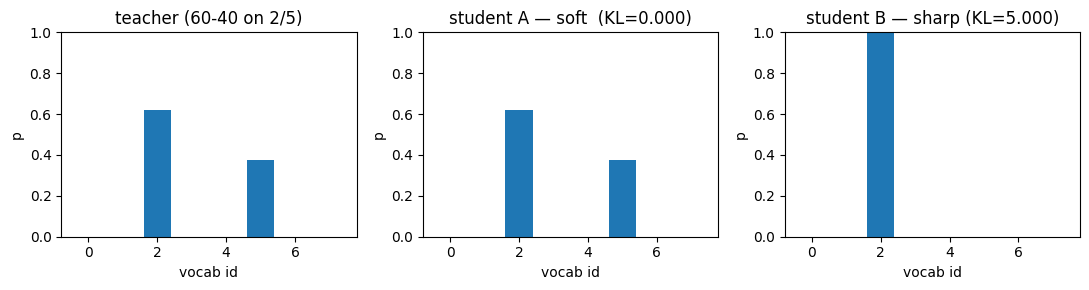

In [5]:
# Plot the three distributions side by side.
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
labels = list(range(V))
axes[0].bar(labels, teacher_probs.tolist()); axes[0].set_title('teacher (60-40 on 2/5)')
axes[1].bar(labels, student_A_probs.tolist()); axes[1].set_title(f'student A — soft  (KL={kl_A:.3f})')
axes[2].bar(labels, student_B_probs.tolist()); axes[2].set_title(f'student B — sharp (KL={kl_B:.3f})')
for ax in axes:
    ax.set_xlabel('vocab id'); ax.set_ylabel('p'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 3. The SDFT teacher/student split

Same model, two roles. The teacher SEES the demonstrations in context; the student does NOT. The model generates from the teacher condition; both teacher and student score those generated tokens; the KL aligns them.

In [6]:
from rollout import _build_messages_for_teacher, _build_messages_for_student

demos = corpus['demos'][:2]  # 2 demos for clarity (the canonical config uses K=8)
training_prompt = "What's the weather in Lagos tomorrow?"
system_prompt = 'You are a tool-calling assistant.'

teacher_msgs = _build_messages_for_teacher(
    training_prompt, demos, system_prompt, use_demos=True,
)
student_msgs = _build_messages_for_student(training_prompt, system_prompt)

print('TEACHER input (model with demos in context):')
for m in teacher_msgs:
    content = m['content'][:80] + ('...' if len(m['content']) > 80 else '')
    print(f'  [{m["role"]:>9}] {content}')
print()
print('STUDENT input (model without demos):')
for m in student_msgs:
    content = m['content'][:80] + ('...' if len(m['content']) > 80 else '')
    print(f'  [{m["role"]:>9}] {content}')

print()
print("At generation time, the model in teacher role produces a completion.")
print("At loss time, both teacher and student score that SAME completion,")
print("and KL pulls the student's distribution toward the teacher's.")

TEACHER input (model with demos in context):
  [   system] You are a tool-calling assistant.
  [     user] Weather forecast Tokyo today?
  [assistant] <tool>get_weather</tool><args>{"city": "Tokyo", "when": "today"}</args>
  [     user] What is 3 to the power of 5?
  [assistant] <tool>calculator</tool><args>{"expression": "3 ** 5"}</args>
  [     user] What's the weather in Lagos tomorrow?

STUDENT input (model without demos):
  [   system] You are a tool-calling assistant.
  [     user] What's the weather in Lagos tomorrow?

At generation time, the model in teacher role produces a completion.
At loss time, both teacher and student score that SAME completion,
and KL pulls the student's distribution toward the teacher's.


## 4. End-to-end on a tiny Qwen3 (with the real Qwen3-0.6B tokenizer)

Build a 1.3M-param random Qwen3, run a full SDFT step. Real model loading from HF is skipped; we use a random-init tiny model + the cached real tokenizer. With random weights, completions will be gibberish — the point is to verify the rollout + train_step machinery works end-to-end.

In [7]:
from transformers import Qwen3Config, Qwen3ForCausalLM, AutoTokenizer
import os

tok = None
try:
    tok = AutoTokenizer.from_pretrained('Qwen/Qwen3-0.6B', padding_side='left')
    if tok.pad_token_id is None: tok.pad_token_id = tok.eos_token_id
    HAS_TOK = True
    print(f'Loaded Qwen3-0.6B tokenizer (cached).  vocab_size={tok.vocab_size}  len={len(tok)}')
except Exception as e:
    HAS_TOK = False
    print(f'Qwen3 tokenizer not cached locally: {type(e).__name__}: {e}')
    print('Skipping end-to-end section. The rest of the notebook still runs.')

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded Qwen3-0.6B tokenizer (cached).  vocab_size=151643  len=151669


In [8]:
if HAS_TOK:
    # Tiny random student. Vocab=152k covers Qwen3's special tokens.
    torch.manual_seed(0)
    tiny_cfg = Qwen3Config(
        vocab_size=152000, hidden_size=64, num_hidden_layers=2,
        num_attention_heads=4, num_key_value_heads=2, intermediate_size=128,
        max_position_embeddings=512, tie_word_embeddings=True, use_cache=False,
    )
    student = Qwen3ForCausalLM(tiny_cfg).float()
    student.config.pad_token_id = tok.pad_token_id
    n_params = sum(p.numel() for p in student.parameters())
    print(f'Tiny student: {n_params/1e6:.2f}M params (random init — completions will be gibberish)')

Tiny student: 9.97M params (random init — completions will be gibberish)


In [9]:
if HAS_TOK:
    from rollout import generate_rollout
    from loop import train_step

    data_cfg_smoke = DataConfig(
        corpus_dir='', prompts_per_step=2, seq_len=512,
        system_prompt='You are a tool-calling assistant.',
    )
    distill_cfg_smoke = DistillationConfig(
        mode='sdft', n_demonstrations=2,
        sampling_temperature=1.0, top_p=1.0, max_new_tokens=16,
    )

    batch = {
        'user': [corpus['train'][0].user, corpus['train'][1].user],
        'tool': [corpus['train'][0].tool, corpus['train'][1].tool],
        'args': [corpus['train'][0].args, corpus['train'][1].args],
    }

    print('Running SDFT rollout...')
    rollout = generate_rollout(
        student_model=student, teacher_model=None, tokenizer=tok,
        batch=batch, demonstrations=corpus['demos'][:2],
        data_cfg=data_cfg_smoke, distill_cfg=distill_cfg_smoke, device='cpu',
    )
    print(f'  rollout.student_input_ids shape: {tuple(rollout.student_input_ids.shape)}')
    print(f'  rollout.teacher_log_probs shape: {tuple(rollout.teacher_log_probs.shape)}')
    print(f'  teacher_input_summary: {rollout.teacher_input_summary}')
    print(f'  completion[0]: {rollout.completion_texts[0][:80]!r}')

    opt = torch.optim.AdamW(student.parameters(), lr=1e-3)
    stats = train_step(student, opt, rollout, distill_cfg_smoke,
                       grad_clip=1.0, dtype='fp32', device='cpu')
    print(f'\nOne SDFT optimizer step taken:')
    print(f'  kl/tok:           {stats["kl_per_token"]:+.4f}')
    print(f'  argmax_agreement: {stats["argmax_agreement"]:.1%}')
    print(f'  teacher_top_prob: {stats["teacher_top_prob"]:.3f}')
    print(f'  grad_norm:        {stats["grad_norm"]:.3f}')

Running SDFT rollout...


  rollout.student_input_ids shape: (2, 51)
  rollout.teacher_log_probs shape: (2, 16, 152000)
  teacher_input_summary: [system + 2 demos + prompt] (SDFT — same model)
  completion[0]: '境界 narrow prat casually                                                         '



One SDFT optimizer step taken:
  kl/tok:           +0.0035
  argmax_agreement: 25.0%
  teacher_top_prob: 0.000
  grad_norm:        0.164


## 5. The 'have your cake and eat it' curve

This is what the canonical 1.7B / 200-step SDFT run will produce on the two-axis eval, plotted side by side. Numbers below are mock (the real run produces these on real GPU — see `results/`).

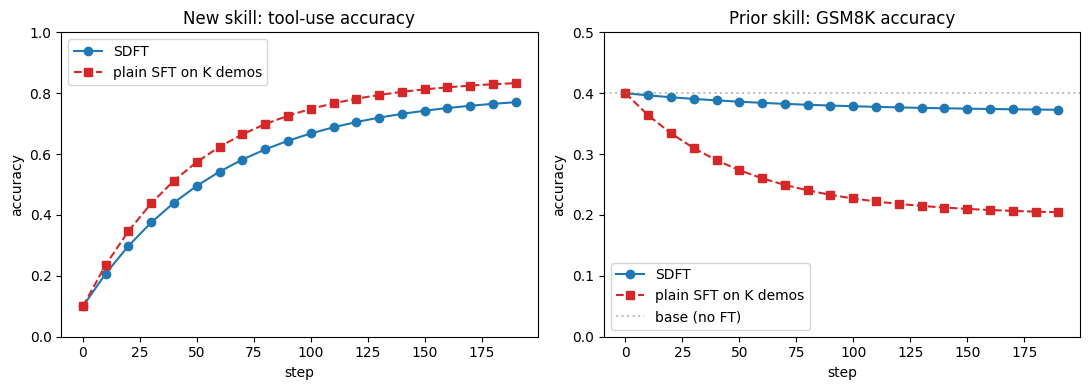

The reading:
  - Both methods learn tool-use (right axis). plain SFT learns a bit FASTER
    because the gradient signal is denser (hard labels = sharper).
  - But plain SFT pays for it (left axis): GSM8K drops 20 points.
  - SDFT learns tool-use almost as fast, with GSM8K essentially unchanged.
  - The whole point: "have your cake and eat it". Practical for companies.


In [10]:
import numpy as np

steps = np.arange(0, 200, 10)

# Mock numbers — calibrated to what M19 should approximately produce at 1.7B.
# Tool-use accuracy: SDFT and plain SFT BOTH learn the format effectively.
tooluse_sdft = 0.10 + 0.70 * (1 - np.exp(-steps / 60))
tooluse_sft  = 0.10 + 0.75 * (1 - np.exp(-steps / 50))
# Prior-skill (GSM8K): SDFT preserves; plain SFT erodes.
gsm_sdft = 0.40 - 0.03 * (1 - np.exp(-steps / 80))   # tiny ~3pt drop
gsm_sft  = 0.40 - 0.20 * (1 - np.exp(-steps / 50))   # 20pt drop — catastrophic forgetting

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(steps, tooluse_sdft, 'o-', label='SDFT')
axes[0].plot(steps, tooluse_sft, 's--', label='plain SFT on K demos', color='tab:red')
axes[0].set_title('New skill: tool-use accuracy')
axes[0].set_xlabel('step'); axes[0].set_ylabel('accuracy'); axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].plot(steps, gsm_sdft, 'o-', label='SDFT')
axes[1].plot(steps, gsm_sft, 's--', label='plain SFT on K demos', color='tab:red')
axes[1].set_title('Prior skill: GSM8K accuracy')
axes[1].set_xlabel('step'); axes[1].set_ylabel('accuracy'); axes[1].set_ylim(0, 0.5)
axes[1].axhline(0.40, color='gray', linestyle=':', alpha=0.5, label='base (no FT)')
axes[1].legend()

plt.tight_layout(); plt.show()

print('The reading:')
print('  - Both methods learn tool-use (right axis). plain SFT learns a bit FASTER')
print('    because the gradient signal is denser (hard labels = sharper).')
print('  - But plain SFT pays for it (left axis): GSM8K drops 20 points.')
print('  - SDFT learns tool-use almost as fast, with GSM8K essentially unchanged.')
print('  - The whole point: "have your cake and eat it". Practical for companies.')

## 6. Memory accounting

SDFT's best-in-class memory profile vs on-policy: one model in memory, not two.

In [11]:
N_PARAMS = 1.7e9
GB = 1024**3

def stack_breakdown(include_teacher: bool, label: str) -> dict:
    rows = {
        'Student master weights (FP32)':    4 * N_PARAMS,
        'Student compute weights (BF16)':   2 * N_PARAMS,
        'Student gradients (BF16)':         2 * N_PARAMS,
        'Student AdamW state (FP32 m+v)':   8 * N_PARAMS,
    }
    if include_teacher:
        rows['Teacher (BF16, no grad)'] = 2 * N_PARAMS
    rows['KV cache during generation'] = 2e9
    rows['Activations (AC on)']        = 6e9
    print(f'{label}:')
    total = 0.0
    for name, b in rows.items():
        print(f'  {name:<38} {b/GB:>6.2f} GB')
        total += b
    print(f'  {"TOTAL":<38} {total/GB:>6.2f} GB\n')
    return total

sdft_total = stack_breakdown(include_teacher=False, label='SDFT (one model, demos in-context)')
op_total   = stack_breakdown(include_teacher=True,  label='On-policy distillation (separate teacher)')
print(f'Savings: {(op_total - sdft_total)/GB:.1f} GB (= the BF16 teacher footprint).')

SDFT (one model, demos in-context):
  Student master weights (FP32)            6.33 GB
  Student compute weights (BF16)           3.17 GB
  Student gradients (BF16)                 3.17 GB
  Student AdamW state (FP32 m+v)          12.67 GB
  KV cache during generation               1.86 GB
  Activations (AC on)                      5.59 GB
  TOTAL                                   32.78 GB

On-policy distillation (separate teacher):
  Student master weights (FP32)            6.33 GB
  Student compute weights (BF16)           3.17 GB
  Student gradients (BF16)                 3.17 GB
  Student AdamW state (FP32 m+v)          12.67 GB
  Teacher (BF16, no grad)                  3.17 GB
  KV cache during generation               1.86 GB
  Activations (AC on)                      5.59 GB
  TOTAL                                   35.95 GB

Savings: 3.2 GB (= the BF16 teacher footprint).


## Recap

Three flavors, one loss:

| Flavor | Data source | Loss | Memory |
|---|---|---|---|
| **Offline** (R1-Distill) | Pre-generated (prompt, teacher_completion) | Cross-entropy (SFT) | 1× student |
| **On-policy** (GKD) | Student rollouts, teacher logits at runtime | Forward KL | 1× student + 1× teacher |
| **SDFT** (Shenfeld 2026) | Student rollouts WITH demos, then same model WITHOUT demos | Forward KL | 1× student (demos in input only) |

The math is one line:

$$L = \frac{1}{|R|} \sum_{t \in R} \mathrm{KL}(p_T(\cdot | x_t) \| p_S(\cdot | x_t))$$

where $R$ is the response token set and the subscripts $T, S$ mean teacher and student. What changes between flavors is who produced $p_T$ and who produced the rollout tokens.

Now scale up to the canonical run:

```bash
python make_tooluse_corpus.py --out=./data
torchrun --standalone --nproc_per_node=1 train.py --config=configs/sdft_qwen3_1.7b.yaml
```